In [1]:
import ROOT
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt

In [4]:
import awkward as ak
from coffea.nanoevents import NanoEventsFactory, NanoAODSchema

file_path = "/eos/user/b/bbapi/MC_contacts/ggH_Run3_private_sample/CMSSW_15_0_15_patch4/src/HAHM_ma30GeV_part2_NanoAOD.root"

factory = NanoEventsFactory.from_root(
    f"{file_path}:Events",
    schemaclass=NanoAODSchema,
)
events = ak.materialize(factory.events())

In [5]:
events.Jet.fields

['chMultiplicity',
 'nConstituents',
 'nElectrons',
 'nMuons',
 'nSVs',
 'neMultiplicity',
 'electronIdx1',
 'electronIdx2',
 'muonIdx1',
 'muonIdx2',
 'svIdx1',
 'svIdx2',
 'hfadjacentEtaStripsSize',
 'hfcentralEtaStripSize',
 'PNetRegPtRawCorr',
 'PNetRegPtRawCorrNeutrino',
 'PNetRegPtRawRes',
 'UParTAK4RegPtRawCorr',
 'UParTAK4RegPtRawCorrNeutrino',
 'UParTAK4RegPtRawRes',
 'UParTAK4V1RegPtRawCorr',
 'UParTAK4V1RegPtRawCorrNeutrino',
 'UParTAK4V1RegPtRawRes',
 'area',
 'btagDeepFlavB',
 'btagDeepFlavCvB',
 'btagDeepFlavCvL',
 'btagDeepFlavQG',
 'btagPNetB',
 'btagPNetCvB',
 'btagPNetCvL',
 'btagPNetCvNotB',
 'btagPNetQvG',
 'btagPNetTauVJet',
 'btagUParTAK4B',
 'btagUParTAK4CvB',
 'btagUParTAK4CvL',
 'btagUParTAK4CvNotB',
 'btagUParTAK4Ele',
 'btagUParTAK4Mu',
 'btagUParTAK4QvG',
 'btagUParTAK4SvCB',
 'btagUParTAK4SvUDG',
 'btagUParTAK4TauVJet',
 'btagUParTAK4UDG',
 'btagUParTAK4probb',
 'btagUParTAK4probbb',
 'chEmEF',
 'chHEF',
 'eta',
 'hfEmEF',
 'hfHEF',
 'hfsigmaEtaEta',
 'hfsi

In [7]:
events.Jet.btagUParTAK4B

<Array [[0.997, 0.00276, ..., -1, 0.0144], ...] type='123 * var * float32[p...'>

In [3]:
gen = events.GenPart

bquarks = gen[abs(gen.pdgId) == 5]
mother_idx = bquarks.genPartIdxMother
from_a_mask = gen[mother_idx].pdgId == 35
bquarks_from_a = bquarks[from_a_mask]

In [5]:
bquarks_from_a.fields

['genPartIdxMother',
 'statusFlags',
 'pdgId',
 'status',
 'eta',
 'mass',
 'phi',
 'pt',
 'genPartIdxMotherG',
 'distinctParentIdxG',
 'childrenIdxG',
 'distinctChildrenIdxG',
 'distinctChildrenDeepIdxG']

In [18]:
bquarks_from_a = bquarks_from_a[ak.argsort(bquarks_from_a.pt, axis=1, ascending=False)]

# leading and subleading jets
b1 = ak.firsts(bquarks_from_a)      # first jet
b2 = bquarks_from_a[:, 1] 

def to_px(pt, phi):
    return pt * np.cos(phi)

def to_py(pt, phi):
    return pt * np.sin(phi)

def to_pz(pt, eta):
    return pt * np.sinh(eta)


px1 = to_px(ak.to_numpy(b1.pt), ak.to_numpy(b1.phi))
py1 = to_py(ak.to_numpy(b1.pt), ak.to_numpy(b1.phi))
pz1 = to_pz(ak.to_numpy(b1.pt), ak.to_numpy(b1.eta))

px2 = to_px(ak.to_numpy(b2.pt), ak.to_numpy(b2.phi))
py2 = to_py(ak.to_numpy(b2.pt), ak.to_numpy(b2.phi))
pz2 = to_pz(ak.to_numpy(b2.pt), ak.to_numpy(b2.eta))

# Dot product
dot = px1*px2 + py1*py2 + pz1*pz2

# Norms
norm1 = np.sqrt(px1**2 + py1**2 + pz1**2)
norm2 = np.sqrt(px2**2 + py2**2 + pz2**2)

# Safe cosine
cos_theta = dot / (norm1 * norm2)
cos_theta = np.clip(cos_theta, -1, 1)

# Angle in radians
theta = np.arccos(cos_theta)

# Optionally degrees
theta_deg = np.degrees(theta)

theta_deg = ak.from_numpy(theta_deg)


In [19]:
theta_deg

<Array [62.5, 89.7, 80.8, 35.5, ..., 67.8, 125, 42.2] type='90717 * ?float32'>

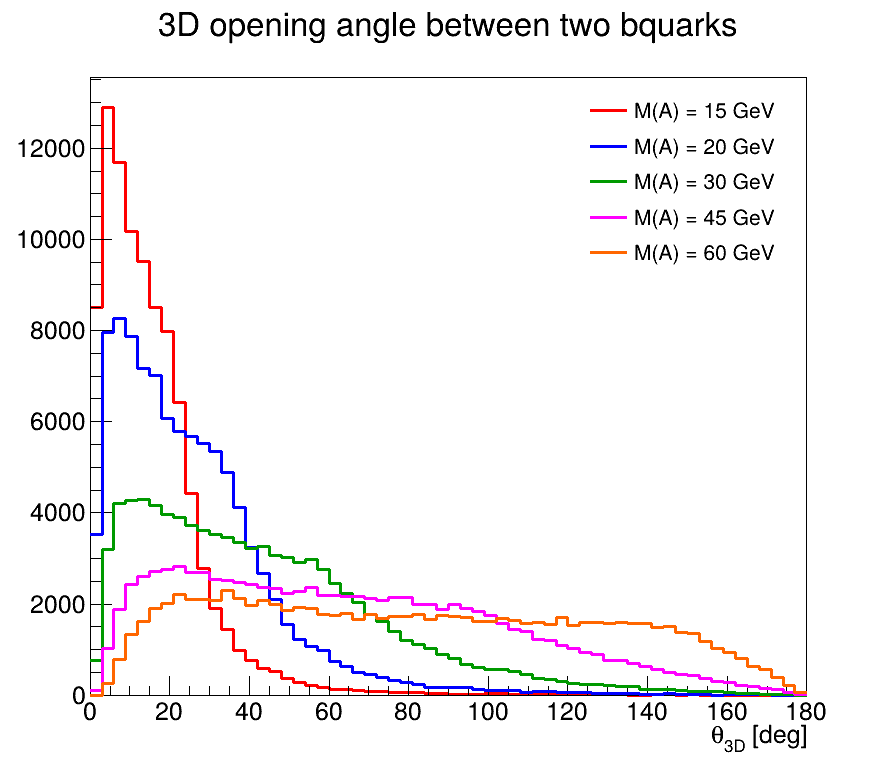

In [20]:
# Convert awkward → flat numpy array
theta_np = ak.to_numpy(theta_deg)

# Create histogram
nbins = 60
xmin = 0
xmax = 180

h = ROOT.TH1F("h_theta", "Opening angle between b quarks;#theta_{3D} [deg];Events", 
              nbins, xmin, xmax)

# Fill histogram
for val in theta_np:
    h.Fill(val)

# Draw
c = ROOT.TCanvas("c", "c", 800, 700)
ROOT.gStyle.SetOptStat(1110)

h.SetLineWidth(2)
h.SetLineColor(ROOT.kBlue + 1)

h.Draw("HIST")

c.Draw()


Processing: /eos/user/b/bbapi/MC_contacts/ggH_Run3_private_sample/CMSSW_13_0_13/src/HAHM_Nano_15_2022.root
Processing: /eos/user/b/bbapi/MC_contacts/ggH_Run3_private_sample/CMSSW_13_0_13/src/HAHM_Nano_15_2022.root
Processing: /eos/user/b/bbapi/MC_contacts/ggH_Run3_private_sample/CMSSW_13_0_13/src/HAHM_Nano_20_2022.root
Processing: /eos/user/b/bbapi/MC_contacts/ggH_Run3_private_sample/CMSSW_13_0_13/src/HAHM_Nano_20_2022.root
Processing: /eos/user/b/bbapi/MC_contacts/ggH_Run3_private_sample/CMSSW_13_0_13/src/HAHM_Nano_30_2022.root
Processing: /eos/user/b/bbapi/MC_contacts/ggH_Run3_private_sample/CMSSW_13_0_13/src/HAHM_Nano_30_2022.root
Processing: /eos/user/b/bbapi/MC_contacts/ggH_Run3_private_sample/CMSSW_13_0_13/src/HAHM_Nano_45_2022.root
Processing: /eos/user/b/bbapi/MC_contacts/ggH_Run3_private_sample/CMSSW_13_0_13/src/HAHM_Nano_45_2022.root
Processing: /eos/user/b/bbapi/MC_contacts/ggH_Run3_private_sample/CMSSW_13_0_13/src/HAHM_Nano_60_2022.root
Processing: /eos/user/b/bbapi/MC_cont

Info in <TCanvas::Print>: pdf file theta3d_overlay_masspoints.pdf has been created
Info in <TCanvas::Print>: png file theta3d_overlay_masspoints.png has been created
Info in <TCanvas::Print>: pdf file dR_overlay_masspoints.pdf has been created
Info in <TCanvas::Print>: png file dR_overlay_masspoints.png has been created


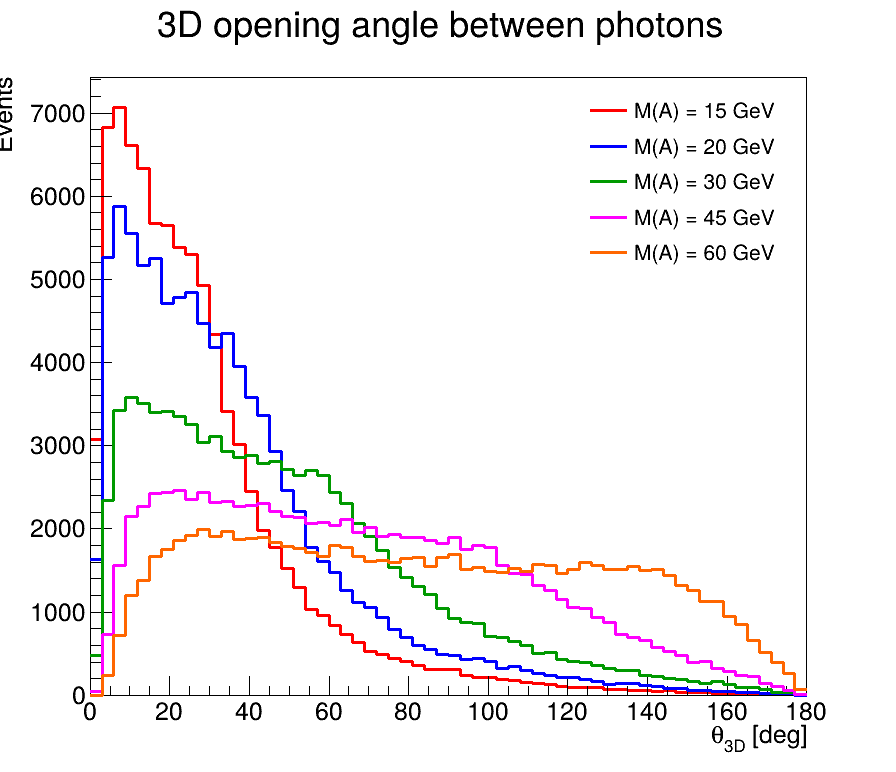

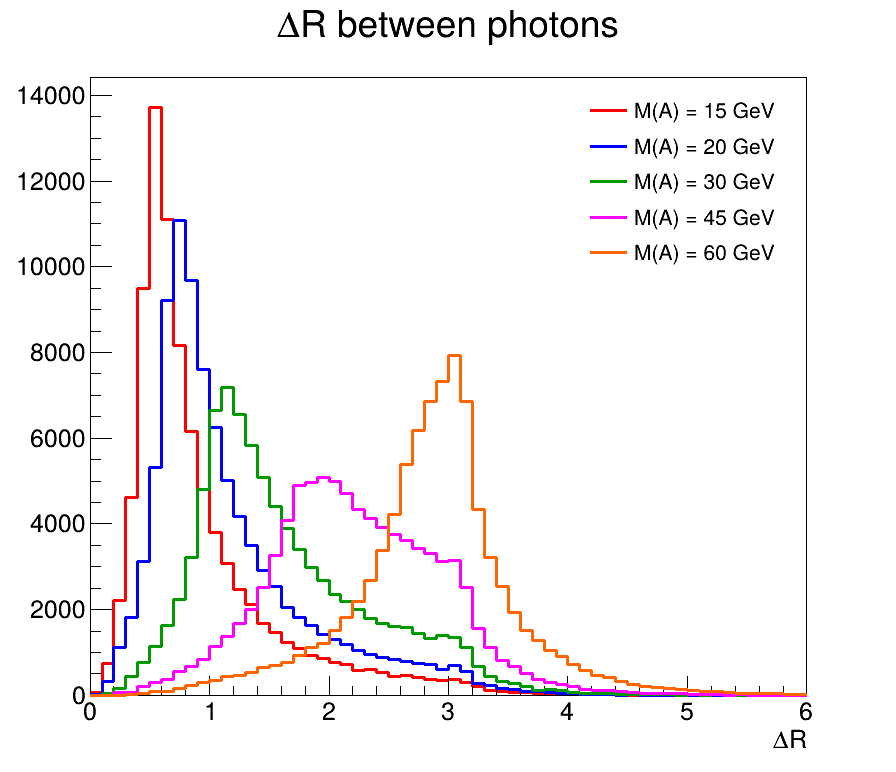

In [ ]:
#!/usr/bin/env python3

import awkward as ak
import numpy as np
import ROOT
from coffea.nanoevents import NanoEventsFactory, NanoAODSchema

# -----------------------------------------------------------
# Mass points and file paths
# -----------------------------------------------------------
mass_points = {
    15: "/eos/user/b/bbapi/MC_contacts/ggH_Run3_private_sample/CMSSW_13_0_13/src/HAHM_Nano_15_2022.root",
    20: "/eos/user/b/bbapi/MC_contacts/ggH_Run3_private_sample/CMSSW_13_0_13/src/HAHM_Nano_20_2022.root",
    30: "/eos/user/b/bbapi/MC_contacts/ggH_Run3_private_sample/CMSSW_13_0_13/src/HAHM_Nano_30_2022.root",
    45: "/eos/user/b/bbapi/MC_contacts/ggH_Run3_private_sample/CMSSW_13_0_13/src/HAHM_Nano_45_2022.root",
    60: "/eos/user/b/bbapi/MC_contacts/ggH_Run3_private_sample/CMSSW_13_0_13/src/HAHM_Nano_60_2022.root",
}

# -----------------------------------------------------------
# Function to compute 3D opening angle from one NanoAOD file
# -----------------------------------------------------------
def compute_theta_deg(path):
    print(f"Processing: {path}")
    events = NanoEventsFactory.from_root(
        f"{path}:Events",
        schemaclass=NanoAODSchema,
    ).events()

    gen = events.GenPart

    # Select gen b-quarks
    bquarks = gen[abs(gen.pdgId) == 5]

    # Their mothers
    mother_idx = bquarks.genPartIdxMother

    # Select those coming from A (pdgId=35)
    from_a = (gen[mother_idx].pdgId == 35)

    b = bquarks[from_a]

    # Need exactly ≥ 2 b quarks
    mask = ak.num(b) >= 2
    b = b[mask]

    # Sort by pt per event
    b_sorted = b[ak.argsort(b.pt, axis=1, ascending=False)]

    # leading and subleading
    b1 = b_sorted[:, 0]
    b2 = b_sorted[:, 1]

    # Convert to 3D vectors
    px1 = b1.pt * np.cos(b1.phi)
    py1 = b1.pt * np.sin(b1.phi)
    pz1 = b1.pt * np.sinh(b1.eta)

    px2 = b2.pt * np.cos(b2.phi)
    py2 = b2.pt * np.sin(b2.phi)
    pz2 = b2.pt * np.sinh(b2.eta)

    # Dot product
    dot = px1*px2 + py1*py2 + pz1*pz2

    # Norms
    norm1 = np.sqrt(px1**2 + py1**2 + pz1**2)
    norm2 = np.sqrt(px2**2 + py2**2 + pz2**2)

    # Cosine and angle
    cos_theta = dot / (norm1 * norm2)
    cos_theta = np.clip(cos_theta, -1, 1)
    theta = np.arccos(cos_theta)

    theta_deg = np.degrees(theta)

    return ak.to_numpy(theta_deg)

def compute_deltaR(path):
    print(f"Processing: {path}")
    events = NanoEventsFactory.from_root(
        f"{path}:Events",
        schemaclass=NanoAODSchema,
    ).events()

    gen = events.GenPart

    # Select gen b-quarks
    bquarks = gen[abs(gen.pdgId) == 5]

    # Their mothers
    mother_idx = bquarks.genPartIdxMother

    # Select those coming from A (pdgId = 35)
    from_a = (gen[mother_idx].pdgId == 35)
    b = bquarks[from_a]

    # Need ≥ 2 b quarks
    mask = ak.num(b) >= 2
    b = b[mask]

    # Sort by pt
    b_sorted = b[ak.argsort(b.pt, axis=1, ascending=False)]

    # Leading and subleading
    b1 = b_sorted[:, 0]
    b2 = b_sorted[:, 1]

    # Δη and Δφ
    deta = b1.eta - b2.eta

    dphi = b1.phi - b2.phi
    dphi = (dphi + np.pi) % (2*np.pi) - np.pi    # wrap into [-π, π]

    # ΔR
    dR = np.sqrt(deta**2 + dphi**2)

    return ak.to_numpy(dR)

colors = {
    15: ROOT.kRed,
    20: ROOT.kBlue,
    30: ROOT.kGreen+2,
    45: ROOT.kMagenta,
    60: ROOT.kOrange+7,
}

nbins_theta = 60
xmin_theta = 0
xmax_theta = 180

nbins_dR = 60
xmin_dR = 0
xmax_dR = 6

hists_theta = {}
hists_dR = {}

# -----------------------------------------------------------
# Compute and fill histograms for all mass points
# -----------------------------------------------------------
for mass, path in mass_points.items():

    # ---------- θ3D ----------
    theta_np = compute_theta_deg(path)
    h_theta = ROOT.TH1F(
        f"h_theta_{mass}",
        f"3D opening angle between two b quarks;#theta_{{3D}} [deg];Events",
        nbins_theta, xmin_theta, xmax_theta
    )

    for v in theta_np:
        h_theta.Fill(v)

    h_theta.SetLineWidth(3)
    h_theta.SetLineColor(colors[mass])
    hists_theta[mass] = h_theta

    # ---------- ΔR ----------
    dR_np = compute_deltaR(path)
    h_dR = ROOT.TH1F(
        f"h_dR_{mass}",
        f"#DeltaR between two b quarks;#DeltaR;Events",
        nbins_dR, xmin_dR, xmax_dR
    )

    for v in dR_np:
        h_dR.Fill(v)

    h_dR.SetLineWidth(3)
    h_dR.SetLineColor(colors[mass])
    hists_dR[mass] = h_dR


# -----------------------------------------------------------
# Canvas 1: θ3D overlay
# -----------------------------------------------------------
c1 = ROOT.TCanvas("c1", "Theta3D", 900, 800)
ROOT.gStyle.SetOptStat(0)

first = True
for mass, h in hists_theta.items():
    if first:
        h.Draw("HIST")
        first = False
    else:
        h.Draw("HIST SAME")

leg1 = ROOT.TLegend(0.65, 0.65, 0.88, 0.88)
leg1.SetBorderSize(0)
leg1.SetFillStyle(0)

for mass, h in hists_theta.items():
    leg1.AddEntry(h, f"M(A) = {mass} GeV", "l")

leg1.Draw()

c1.SaveAs("theta3d_overlay_masspoints.pdf")
c1.SaveAs("theta3d_overlay_masspoints.png")

print("Saved theta3d plots.")


# -----------------------------------------------------------
# Canvas 2: ΔR overlay
# -----------------------------------------------------------
c2 = ROOT.TCanvas("c2", "DeltaR", 900, 800)
ROOT.gStyle.SetOptStat(0)

first = True
for mass, h in hists_dR.items():
    if first:
        h.Draw("HIST")
        first = False
    else:
        h.Draw("HIST SAME")

leg2 = ROOT.TLegend(0.65, 0.65, 0.88, 0.88)
leg2.SetBorderSize(0)
leg2.SetFillStyle(0)

for mass, h in hists_dR.items():
    leg2.AddEntry(h, f"M(A) = {mass} GeV", "l")

leg2.Draw()

c2.SaveAs("dR_overlay_masspoints.pdf")
c2.SaveAs("dR_overlay_masspoints.png")

print("Saved dR plots.")



In [9]:
#!/usr/bin/env python3

import awkward as ak
import numpy as np
import ROOT
from coffea.nanoevents import NanoEventsFactory, NanoAODSchema

# -----------------------------------------------------------
# Mass points and file paths
# -----------------------------------------------------------
mass_points = {
    15: "/eos/user/b/bbapi/MC_contacts/ggH_Run3_private_sample/CMSSW_13_0_13/src/HAHM_Nano_15_2022.root",
    20: "/eos/user/b/bbapi/MC_contacts/ggH_Run3_private_sample/CMSSW_13_0_13/src/HAHM_Nano_20_2022.root",
    30: "/eos/user/b/bbapi/MC_contacts/ggH_Run3_private_sample/CMSSW_13_0_13/src/HAHM_Nano_30_2022.root",
    45: "/eos/user/b/bbapi/MC_contacts/ggH_Run3_private_sample/CMSSW_13_0_13/src/HAHM_Nano_45_2022.root",
    60: "/eos/user/b/bbapi/MC_contacts/ggH_Run3_private_sample/CMSSW_13_0_13/src/HAHM_Nano_60_2022.root",
}

# -----------------------------------------------------------
# Function to compute 3D opening angle for photons
# -----------------------------------------------------------
def compute_theta_deg(path):
    print(f"Processing: {path}")
    events = NanoEventsFactory.from_root(
        f"{path}:Events",
        schemaclass=NanoAODSchema,
    ).events()

    gen = events.GenPart

    # Final state photons
    photons = gen[(gen.pdgId == 22) & (gen.status == 1)]

    mother_idx = photons.genPartIdxMother
    from_a_mask = gen[mother_idx].pdgId == 35

    photons_from_a = photons[from_a_mask]

    # Need ≥ 2 photons
    mask = ak.num(photons_from_a) >= 2
    photons_from_a = photons_from_a[mask]

    # Sort by pt
    ph_sorted = photons_from_a[ak.argsort(photons_from_a.pt, axis=1, ascending=False)]

    # Leading and subleading photons
    ph1 = ph_sorted[:, 0]
    ph2 = ph_sorted[:, 1]

    # Convert to 3D momentum vectors
    px1 = ph1.pt * np.cos(ph1.phi)
    py1 = ph1.pt * np.sin(ph1.phi)
    pz1 = ph1.pt * np.sinh(ph1.eta)

    px2 = ph2.pt * np.cos(ph2.phi)
    py2 = ph2.pt * np.sin(ph2.phi)
    pz2 = ph2.pt * np.sinh(ph2.eta)

    # Dot product & magnitudes
    dot = px1*px2 + py1*py2 + pz1*pz2

    norm1 = np.sqrt(px1**2 + py1**2 + pz1**2)
    norm2 = np.sqrt(px2**2 + py2**2 + pz2**2)

    cos_theta = dot / (norm1 * norm2)
    cos_theta = np.clip(cos_theta, -1, 1)

    theta = np.arccos(cos_theta)
    theta_deg = np.degrees(theta)

    return ak.to_numpy(theta_deg)


# -----------------------------------------------------------
# Compute ΔR for photons
# -----------------------------------------------------------
def compute_deltaR(path):
    print(f"Processing: {path}")
    events = NanoEventsFactory.from_root(
        f"{path}:Events",
        schemaclass=NanoAODSchema,
    ).events()

    gen = events.GenPart

    photons = gen[(gen.pdgId == 22) & (gen.status == 1)]

    mother_idx = photons.genPartIdxMother
    from_a_mask = gen[mother_idx].pdgId == 35

    photons_from_a = photons[from_a_mask]

    # Need ≥ 2 photons
    mask = ak.num(photons_from_a) >= 2
    photons_from_a = photons_from_a[mask]

    # Sort by pt
    ph_sorted = photons_from_a[ak.argsort(photons_from_a.pt, axis=1, ascending=False)]

    ph1 = ph_sorted[:, 0]
    ph2 = ph_sorted[:, 1]

    deta = ph1.eta - ph2.eta

    dphi = ph1.phi - ph2.phi
    dphi = (dphi + np.pi) % (2*np.pi) - np.pi

    dR = np.sqrt(deta**2 + dphi**2)

    return ak.to_numpy(dR)


# -----------------------------------------------------------
# ROOT Styling Setup
# -----------------------------------------------------------
colors = {
    15: ROOT.kRed,
    20: ROOT.kBlue,
    30: ROOT.kGreen+2,
    45: ROOT.kMagenta,
    60: ROOT.kOrange+7,
}

nbins_theta = 60
xmin_theta = 0
xmax_theta = 180

nbins_dR = 60
xmin_dR = 0
xmax_dR = 6

hists_theta = {}
hists_dR = {}

# -----------------------------------------------------------
# Compute and fill histograms
# -----------------------------------------------------------
for mass, path in mass_points.items():

    theta_np = compute_theta_deg(path)
    h_theta = ROOT.TH1F(
        f"h_theta_{mass}",
        f"3D opening angle between photons;#theta_{{3D}} [deg];Events",
        nbins_theta, xmin_theta, xmax_theta
    )
    for v in theta_np:
        h_theta.Fill(v)
    h_theta.SetLineWidth(3)
    h_theta.SetLineColor(colors[mass])
    hists_theta[mass] = h_theta

    dR_np = compute_deltaR(path)
    h_dR = ROOT.TH1F(
        f"h_dR_{mass}",
        f"#DeltaR between photons;#DeltaR;Events",
        nbins_dR, xmin_dR, xmax_dR
    )
    for v in dR_np:
        h_dR.Fill(v)
    h_dR.SetLineWidth(3)
    h_dR.SetLineColor(colors[mass])
    hists_dR[mass] = h_dR


# -----------------------------------------------------------
# Canvas 1: θ3D overlay
# -----------------------------------------------------------
c1 = ROOT.TCanvas("c1", "Theta3D", 900, 800)
ROOT.gStyle.SetOptStat(0)

first = True
for mass, h in hists_theta.items():
    if first:
        h.Draw("HIST")
        first = False
    else:
        h.Draw("HIST SAME")

leg1 = ROOT.TLegend(0.65, 0.65, 0.88, 0.88)
leg1.SetBorderSize(0)
leg1.SetFillStyle(0)
for mass, h in hists_theta.items():
    leg1.AddEntry(h, f"M(A) = {mass} GeV", "l")
leg1.Draw()

c1.SaveAs("theta3d_photons_overlay.pdf")
c1.SaveAs("theta3d_photons_overlay.png")

print("Saved theta3d plots.")


# -----------------------------------------------------------
# Canvas 2: ΔR overlay
# -----------------------------------------------------------
c2 = ROOT.TCanvas("c2", "DeltaR", 900, 800)
ROOT.gStyle.SetOptStat(0)

first = True
for mass, h in hists_dR.items():
    if first:
        h.Draw("HIST")
        first = False
    else:
        h.Draw("HIST SAME")

leg2 = ROOT.TLegend(0.65, 0.65, 0.88, 0.88)
leg2.SetBorderSize(0)
leg2.SetFillStyle(0)
for mass, h in hists_dR.items():
    leg2.AddEntry(h, f"M(A) = {mass} GeV", "l")
leg2.Draw()

c2.SaveAs("dR_photons_overlay.pdf")
c2.SaveAs("dR_photons_overlay.png")

print("Saved dR plots.")


Processing: /eos/user/b/bbapi/MC_contacts/ggH_Run3_private_sample/CMSSW_13_0_13/src/HAHM_Nano_15_2022.root
Processing: /eos/user/b/bbapi/MC_contacts/ggH_Run3_private_sample/CMSSW_13_0_13/src/HAHM_Nano_15_2022.root
Processing: /eos/user/b/bbapi/MC_contacts/ggH_Run3_private_sample/CMSSW_13_0_13/src/HAHM_Nano_20_2022.root
Processing: /eos/user/b/bbapi/MC_contacts/ggH_Run3_private_sample/CMSSW_13_0_13/src/HAHM_Nano_20_2022.root
Processing: /eos/user/b/bbapi/MC_contacts/ggH_Run3_private_sample/CMSSW_13_0_13/src/HAHM_Nano_30_2022.root
Processing: /eos/user/b/bbapi/MC_contacts/ggH_Run3_private_sample/CMSSW_13_0_13/src/HAHM_Nano_30_2022.root
Processing: /eos/user/b/bbapi/MC_contacts/ggH_Run3_private_sample/CMSSW_13_0_13/src/HAHM_Nano_45_2022.root
Processing: /eos/user/b/bbapi/MC_contacts/ggH_Run3_private_sample/CMSSW_13_0_13/src/HAHM_Nano_45_2022.root
Processing: /eos/user/b/bbapi/MC_contacts/ggH_Run3_private_sample/CMSSW_13_0_13/src/HAHM_Nano_60_2022.root
Processing: /eos/user/b/bbapi/MC_cont

Warning in <TROOT::Append>: Replacing existing TH1: h_dR_60 (Potential memory leak).
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c1
Info in <TCanvas::Print>: pdf file theta3d_photons_overlay.pdf has been created
Info in <TCanvas::Print>: png file theta3d_photons_overlay.png has been created
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c2
Info in <TCanvas::Print>: pdf file dR_photons_overlay.pdf has been created
Info in <TCanvas::Print>: png file dR_photons_overlay.png has been created
